In [1]:
import model
import epidemic_simulation
import survey_design
import random
import numpy as np
import scipy.stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import arviz
import cmdstanpy
from cmdstanpy import CmdStanModel

In [4]:
random.seed(123)
np.random.seed(123)

In [5]:
f_infectious, f_recovered, delay_inf, delay_recov = epidemic_simulation.delays()
transmission_rate = epidemic_simulation.transmission_rate

In [6]:
inference_model = CmdStanModel(stan_file='model_rw2.stan', cpp_options={'STAN_THREADS':'true'})

sample_sizes = [12, 25, 50, 100,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))

spacings = [1] * len(prev_sample_sizes)

dfs = []
all_scores = []
all_fits = []
all_expanded_scores = []
all_scores_energy = []
all_coverages = []
all_widths = []


In [7]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low_2', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


18:17:13 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/qmr85m0h.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/prnfoiqf.json
init = 2 (Default)
random
  seed = 2391936988 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2hlj2gqby/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 1 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00558, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


18:17:13 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

18:20:25 - cmdstanpy - INFO - CmdStan done processing.
18:20:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.03395, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.02175, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.01184, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00161, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 t

18:20:26 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/yl3t_59p.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/l4727753.json
init = 2 (Default)
random
  seed = 2392130576 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2wb421rri/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00499, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


18:20:27 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

19:32:37 - cmdstanpy - INFO - CmdStan done processing.
19:32:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 22.2641, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.13933, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 

19:32:38 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/v_6bzckx.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/rob5nbz1.json
init = 2 (Default)
random
  seed = 2396462602 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2qhl_acvq/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00155, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


19:32:39 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

19:41:12 - cmdstanpy - INFO - CmdStan done processing.
19:41:12 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 24.8894, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


In [8]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low_2', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


20:32:06 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/o34p99o5.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/ou17d730.json
init = 2 (Default)
random
  seed = 2400030217 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw24x9tkqpm/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00186, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


20:32:06 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

20:34:55 - cmdstanpy - INFO - CmdStan done processing.
20:34:55 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 40.1394, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00454, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00165, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to col

20:34:57 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/cshwlcgu.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/ge7vrm_r.json
init = 2 (Default)
random
  seed = 2400201309 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw28nrmsjzt/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00025, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


20:34:57 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

22:08:29 - cmdstanpy - INFO - CmdStan done processing.
22:08:29 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00748, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00276, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.14565, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00387, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 

22:08:31 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

22:20:14 - cmdstanpy - INFO - CmdStan done processing.
22:20:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [9]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low_2', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


22:33:50 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/mhr_psq_.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/z_gqnex9.json
init = 2 (Default)
random
  seed = 2407333820 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw26ip4jtde/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.01255, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


22:33:50 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

22:36:41 - cmdstanpy - INFO - CmdStan done processing.
22:36:41 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00242, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.01485, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00072, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
Consider re-running with show_console=True if the above output is unclear!


22:36:43 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/6jkxtv0j.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/naqkkiz9.json
init = 2 (Default)
random
  seed = 2407507430 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2vss2h5jn/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00459, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


22:36:43 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

00:23:45 - cmdstanpy - INFO - CmdStan done processing.
00:23:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

00:23:47 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/za2tfdbd.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/1x_idba1.json
init = 2 (Default)
random
  seed = 2413931419 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2l5pbuu0t/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00474, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


00:23:48 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

00:39:05 - cmdstanpy - INFO - CmdStan done processing.
00:39:05 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 72256.8, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


In [10]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low_2', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

06:31:35 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/t8vpcx5x.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/yumitbu5.json
init = 2 (Default)
random
  seed = 2435999710 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2r0zr42yj/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.0062, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


06:31:36 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  lo

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

06:34:42 - cmdstanpy - INFO - CmdStan done processing.
06:34:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.52567e+180, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 2.29391, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.02883, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 t

06:34:44 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/8o7a4vzs.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/d2bquw4h.json
init = 2 (Default)
random
  seed = 2436188560 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2fhpwsgq2/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00015, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


06:34:45 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

08:06:47 - cmdstanpy - INFO - CmdStan done processing.
08:06:47 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.01059, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00054, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.11899, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.05675, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 t

08:06:49 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/wd4n237n.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/eytpa05k.json
init = 2 (Default)
random
  seed = 2441713299 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2nsvip39_/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00048, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


08:06:49 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

08:15:31 - cmdstanpy - INFO - CmdStan done processing.
08:15:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [11]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low_2', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

09:38:15 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/ano3kddv.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/3xz5zaic.json
init = 2 (Default)
random
  seed = 2447199331 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2t355pt3z/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00249, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


09:38:15 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

09:40:49 - cmdstanpy - INFO - CmdStan done processing.
09:40:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is 2845.59, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.16709, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.16063, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00392, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
Consider re-running with show_console=True if the above output is unclear!


09:40:51 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/tvnnt1ad.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/q6d4d6z1.json
init = 2 (Default)
random
  seed = 2447355620 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2u0n2iu7n/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00839, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


09:40:51 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

11:13:33 - cmdstanpy - INFO - CmdStan done processing.
11:13:33 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

11:13:34 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/0pdd778w.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/673gs0qc.json
init = 2 (Default)
random
  seed = 2452918796 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2mltt2gpr/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00804, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


11:13:35 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

11:29:41 - cmdstanpy - INFO - CmdStan done processing.
11:29:41 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 8.25207e+12, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 

In [12]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low_2', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

11:51:44 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/tghoovdo.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/pbv16yt1.json
init = 2 (Default)
random
  seed = 2455208685 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2xjxgelkh/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00448, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


11:51:45 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

11:55:58 - cmdstanpy - INFO - CmdStan done processing.
11:55:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is 1.07813, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.01367, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00713, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.07572, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
Consider re-running with show_console=True if the above output is unclear!


11:55:59 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/y1lyaid5.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/zyq7m2wj.json
init = 2 (Default)
random
  seed = 2455463617 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2tmxodeac/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00271, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


11:55:59 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

13:30:34 - cmdstanpy - INFO - CmdStan done processing.
13:30:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 5.01223e+06, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.27959, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to col

13:30:36 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/zhvvkvbz.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/0s_bu1_n.json
init = 2 (Default)
random
  seed = 2461139882 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2c3fraqqa/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00594, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


13:30:36 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

13:41:21 - cmdstanpy - INFO - CmdStan done processing.
13:41:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00644, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00125, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00091, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.01186, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 

In [13]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low_2', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

13:48:45 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/i010790g.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/z61adn7w.json
init = 2 (Default)
random
  seed = 2462229217 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2qo_v6jyi/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00148, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


13:48:45 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

13:51:26 - cmdstanpy - INFO - CmdStan done processing.
13:51:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 2.47681e+11, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.25248, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to col

13:51:29 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/s3e78aa4.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/yqfh3af1.json
init = 2 (Default)
random
  seed = 2462393005 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw22iuqb_g8/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00159, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


13:51:29 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

15:28:01 - cmdstanpy - INFO - CmdStan done processing.
15:28:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 3.08875, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


15:28:03 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/o4_shki0.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/kffo8hwe.json
init = 2 (Default)
random
  seed = 2468187499 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp3ldawvgj/model_rw2horv56sc/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00674, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


15:28:04 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

15:37:30 - cmdstanpy - INFO - CmdStan done processing.
15:37:30 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 5.48045, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


In [7]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


19:30:10 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/g20mmerp.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/xds8yrak.json
init = 2 (Default)
random
  seed = 1964314258 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw2umekpg2k/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 1 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00558, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


19:30:10 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

19:33:22 - cmdstanpy - INFO - CmdStan done processing.
19:33:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.03395, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.02175, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.01184, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00161, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 t

19:33:23 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/1x9xyfdy.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/asp64lfx.json
init = 2 (Default)
random
  seed = 1964507651 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw2my696ats/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00499, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


19:33:24 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

20:45:31 - cmdstanpy - INFO - CmdStan done processing.
20:45:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 22.2641, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.13933, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 

20:45:32 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/muezr7_4.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/fjwol7f3.json
init = 2 (Default)
random
  seed = 1968836698 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw2sji4oqyw/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00155, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


20:45:33 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

20:52:45 - cmdstanpy - INFO - CmdStan done processing.
20:52:45 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 24.8894, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


In [16]:
np.save('rolling_scores_low_2', np.asarray(all_scores))

In [12]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


21:25:49 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/l_fo7ls9.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/lrn56wpc.json
init = 2 (Default)
random
  seed = 1971253165 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw2rowveq1d/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00186, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


21:25:49 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

21:27:55 - cmdstanpy - INFO - CmdStan done processing.
21:27:55 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 40.1394, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00454, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00165, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to col

21:27:57 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/k5gb2ro6.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/km38kxlv.json
init = 2 (Default)
random
  seed = 1971381166 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw2kem_udyr/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00025, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


21:27:57 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

22:42:36 - cmdstanpy - INFO - CmdStan done processing.
22:42:36 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00748, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00276, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.14565, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00387, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 

22:42:38 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

22:52:11 - cmdstanpy - INFO - CmdStan done processing.
22:52:11 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [13]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling_low', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


23:33:31 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/7kdqli1e.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/gn41ky_0.json
init = 2 (Default)
random
  seed = 1978915200 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw2e5zu50s4/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.01255, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


23:33:31 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

23:35:50 - cmdstanpy - INFO - CmdStan done processing.
23:35:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00242, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.01485, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00072, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
Consider re-running with show_console=True if the above output is unclear!


23:35:51 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/u7dd8hr7.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/8xe_kzcz.json
init = 2 (Default)
random
  seed = 1979055703 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw23bods_ak/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00459, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


23:35:52 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

01:02:00 - cmdstanpy - INFO - CmdStan done processing.
01:02:00 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

01:02:02 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/k9mlpm01.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/vqvmhb2x.json
init = 2 (Default)
random
  seed = 1984226027 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp2o_f7erd/model_rw2ycwp2prj/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00474, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


01:02:02 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

01:13:50 - cmdstanpy - INFO - CmdStan done processing.
01:13:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 72256.8, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


In [4]:
inference_model = CmdStanModel(stan_file='model_rw2.stan', cpp_options={'STAN_THREADS':'true'})

sample_sizes = [100, 200, 400, 800,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))

spacings = [1] * len(prev_sample_sizes)

num_repeats = 10

dfs = []
all_scores = []
all_fits = []
all_expanded_scores = []
all_scores_energy = []
all_coverages = []
all_widths = []


In [ ]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


18:31:58 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/inblhcuh.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/h59xkd9_.json
init = 2 (Default)
random
  seed = 3750189940 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2rc53q9nh/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 1 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00865, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


18:31:59 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

18:41:01 - cmdstanpy - INFO - CmdStan done processing.
18:41:01 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 45.1249, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


18:41:02 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/zy_ell0v.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/w671_te3.json
init = 2 (Default)
random
  seed = 3750733791 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2sivs5vpr/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00721, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


18:41:03 - cmdstanpy - INFO - CmdStan start processing


...

22:07:25 - cmdstanpy - INFO - CmdStan done processing.


22:07:26 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/6h4559be.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/msl4qq2e.json
init = 2 (Default)
random
  seed = 3763117871 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2c5jzgjqt/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00318, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


22:07:27 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

22:36:20 - cmdstanpy - INFO - CmdStan done processing.


In [ ]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
# all_scores.append(scores)
# all_fits.append(fits)
# all_expanded_scores.append(expanded_scores)

# all_scores_energy.append(scores_energy)

# all_coverages.append(coverage)
# all_widths.append(width)


22:49:01 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/0hi9u6gp.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/81wzrvyl.json
init = 2 (Default)
random
  seed = 3765612235 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2fu_zfvp2/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00699, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


22:49:01 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

22:57:00 - cmdstanpy - INFO - CmdStan done processing.
22:57:00 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 3.51908e+28, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 

22:57:01 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/b12et196.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/9vpf3h1p.json
init = 2 (Default)
random
  seed = 3766092768 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2_w_yjfly/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00122, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


22:57:01 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

02:28:47 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/20wb_ysm.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/4xa1p4uy.json
init = 2 (Default)
random
  seed = 3778798826 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2gmh0i7md/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00297, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


02:28:47 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

02:47:02 - cmdstanpy - INFO - CmdStan done processing.
02:47:02 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [17]:
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)

all_coverages.append(coverage)
all_widths.append(width)

In [42]:
all_scores

array([[0.15633047, 0.13039446, 0.13323197, 0.09274152, 0.11368488,
        0.09539414, 0.10522569, 0.10676775, 0.09737542, 0.0832478 ,
        0.08163112, 0.09338807, 0.08280088, 0.09206704, 0.07733733,
        0.07902991],
       [0.13284987, 0.10738528, 0.10525303, 0.11024304, 0.09168978,
        0.10295727, 0.10321112, 0.1519714 , 0.09108546, 0.07981928,
        0.08956167, 0.08521412, 0.07279021, 0.08307033, 0.08121309,
        0.07448521],
       [0.10403715, 0.12441134, 0.09903127, 0.10357936, 0.10570989,
        0.10844318, 0.095115  , 0.0893542 , 0.10088284, 0.08908603,
        0.11096897, 0.07742227, 0.08102066, 0.07584291, 0.08150473,
        0.07393143]])

In [13]:
scores

[np.float64(0.13284986991266545),
 np.float64(0.10738528059166677),
 np.float64(0.10525302780132167),
 np.float64(0.11024304159550048),
 np.float64(0.09168978320140736),
 np.float64(0.10295726783361689),
 np.float64(0.1032111171997189),
 np.float64(0.15197140133747356),
 np.float64(0.09108545624420625),
 np.float64(0.07981928202604727),
 np.float64(0.08956166821764486),
 np.float64(0.08521412048164037),
 np.float64(0.07279020876309567),
 np.float64(0.08307033438529271),
 np.float64(0.08121309412792736),
 np.float64(0.07448521455367176)]

In [43]:
all_scores = list(all_scores)

In [15]:
all_scores

[array([0.15633047, 0.13039446, 0.13323197, 0.09274152, 0.11368488,
        0.09539414, 0.10522569, 0.10676775, 0.09737542, 0.0832478 ,
        0.08163112, 0.09338807, 0.08280088, 0.09206704, 0.07733733,
        0.07902991])]

In [44]:
all_scores_energy = list(all_scores_energy)

In [18]:
all_scores

[array([0.15633047, 0.13039446, 0.13323197, 0.09274152, 0.11368488,
        0.09539414, 0.10522569, 0.10676775, 0.09737542, 0.0832478 ,
        0.08163112, 0.09338807, 0.08280088, 0.09206704, 0.07733733,
        0.07902991]),
 [np.float64(0.13284986991266545),
  np.float64(0.10738528059166677),
  np.float64(0.10525302780132167),
  np.float64(0.11024304159550048),
  np.float64(0.09168978320140736),
  np.float64(0.10295726783361689),
  np.float64(0.1032111171997189),
  np.float64(0.15197140133747356),
  np.float64(0.09108545624420625),
  np.float64(0.07981928202604727),
  np.float64(0.08956166821764486),
  np.float64(0.08521412048164037),
  np.float64(0.07279020876309567),
  np.float64(0.08307033438529271),
  np.float64(0.08121309412792736),
  np.float64(0.07448521455367176)]]

In [ ]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


03:28:24 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

03:36:35 - cmdstanpy - INFO - CmdStan done processing.
03:36:35 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00181, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.01641, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
Consider re-running with show_console=True if the above output is unclear!


03:36:37 - cmdstanpy - INFO - CmdStan start processing


...

07:11:58 - cmdstanpy - INFO - CmdStan done processing.
07:11:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 9.96395e+26, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
Consider re-running with show_console=True if the above output is unclear!


07:12:00 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

07:33:30 - cmdstanpy - INFO - CmdStan done processing.
07:33:30 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [ ]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)


16:50:44 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/brol3y8p.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/rgefmhxv.json
init = 2 (Default)
random
  seed = 3830515406 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2lbqkm_qb/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00269, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


16:50:44 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

17:03:53 - cmdstanpy - INFO - CmdStan done processing.
17:03:53 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 2.63905, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


17:03:55 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/gg160lmj.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/nny__kjx.json
init = 2 (Default)
random
  seed = 3831306377 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw261agd2s7/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.01233, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


17:03:55 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

21:56:07 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/zx6f5g0t.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/0uabxsm1.json
init = 2 (Default)
random
  seed = 3848838909 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw22d9jotq8/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.01305, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


21:56:08 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

22:28:26 - cmdstanpy - INFO - CmdStan done processing.


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [47]:
all_widths = list(all_widths)
all_widths.append(width)

In [50]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)


22:39:37 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/rfigk4q6.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/tbdpy1q7.json
init = 2 (Default)
random
  seed = 3851448809 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw24zv5a9by/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00176, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


22:39:37 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

22:48:30 - cmdstanpy - INFO - CmdStan done processing.
22:48:30 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.73387e+61, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 

22:48:31 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/pfzy4kcg.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/4ssictcb.json
init = 2 (Default)
random
  seed = 3851982533 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2_xpd5jtb/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00301, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


22:48:31 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

02:15:13 - cmdstanpy - INFO - CmdStan done processing.
02:15:13 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1881.91, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
Consider re-running with show_console=True if the above output is unclear!


02:15:14 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/erdvh8w3.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/c6z44dpj.json
init = 2 (Default)
random
  seed = 3864385450 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2wjqyu8dn/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00288, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


02:15:14 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

02:33:00 - cmdstanpy - INFO - CmdStan done processing.
02:33:00 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [52]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

02:56:06 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/ly793xqw.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/y09s_8ql.json
init = 2 (Default)
random
  seed = 3866837576 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2np17h4by/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00328, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


02:56:06 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

03:03:48 - cmdstanpy - INFO - CmdStan done processing.
03:03:48 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is 1.00088, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00522, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.01866, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
Consider re-running with show_console=True if the above output is unclear!


03:03:49 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/6dsipkiy.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/ah2h8g7u.json
init = 2 (Default)
random
  seed = 3867300923 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2d0d26lcz/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00538, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


03:03:49 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

06:59:34 - cmdstanpy - INFO - CmdStan done processing.
06:59:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.00064, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
Consider re-running with show_console=True if the above output is unclear!


06:59:36 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/f_l4aate.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/jhzy6k6a.json
init = 2 (Default)
random
  seed = 3881447434 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2y8n_9r_c/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.0099, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


06:59:36 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  lo

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

07:19:14 - cmdstanpy - INFO - CmdStan done processing.
07:19:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [54]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

10:27:46 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

10:35:13 - cmdstanpy - INFO - CmdStan done processing.
10:35:13 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 19.3185, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


10:35:15 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/1kmc5hbh.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/mwf4s4au.json
init = 2 (Default)
random
  seed = 3894386659 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2p_vkaeq_/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00491, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


10:35:15 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

14:20:46 - cmdstanpy - INFO - CmdStan done processing.
14:20:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

14:20:48 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/x4l03axy.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/0atug5f8.json
init = 2 (Default)
random
  seed = 3907919464 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2bng356kq/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00125, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


14:20:48 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

14:39:40 - cmdstanpy - INFO - CmdStan done processing.
14:39:40 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [56]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

15:04:18 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/64brk8aa.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/7h6c8xud.json
init = 2 (Default)
random
  seed = 3910529518 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2z0v2pqzk/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00049, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


15:04:18 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

15:12:23 - cmdstanpy - INFO - CmdStan done processing.
15:12:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is 1.22417, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)


15:12:25 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/1aihr4hu.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/qb3u548u.json
init = 2 (Default)
random
  seed = 3911016244 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2e5r17r5o/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.0029, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


15:12:25 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  lo

...

18:27:36 - cmdstanpy - INFO - CmdStan done processing.
18:27:36 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

18:27:38 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/oee2hna3.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/f71sehk8.json
init = 2 (Default)
random
  seed = 3922729361 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2a0n7fj2o/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00302, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


18:27:38 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

18:47:17 - cmdstanpy - INFO - CmdStan done processing.
18:47:17 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
Consider re-running with show_console=True if the above output is unclear!


In [62]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)
all_coverages.append(coverage)
all_widths.append(width)

19:05:26 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/pn17nl42.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/x4v0zlfu.json
init = 2 (Default)
random
  seed = 3924997433 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2rae9lcsi/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.01662, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


19:05:26 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

19:17:41 - cmdstanpy - INFO - CmdStan done processing.
19:17:41 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is 1.00082, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.0025, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
Consider re-running with show_console=True if the above output is unclear!


19:17:42 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/s3j473yr.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/mggxsvay.json
init = 2 (Default)
random
  seed = 3925733978 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2qh44usa6/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00029, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


19:17:43 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

...

23:53:15 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/zm4bb9xp.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/3hmxj5gw.json
init = 2 (Default)
random
  seed = 3942266608 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2eaqg8au8/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00823, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


23:53:15 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

00:24:13 - cmdstanpy - INFO - CmdStan done processing.


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [78]:
np.save('rolling_scores', np.asarray(all_scores))
np.save('rolling_scores_energy', np.asarray(all_scores_energy))
np.save('rolling_widths', np.asarray(all_widths))

In [59]:
all_scores

[array([0.15633047, 0.13039446, 0.13323197, 0.09274152, 0.11368488,
        0.09539414, 0.10522569, 0.10676775, 0.09737542, 0.0832478 ,
        0.08163112, 0.09338807, 0.08280088, 0.09206704, 0.07733733,
        0.07902991]),
 array([0.13284987, 0.10738528, 0.10525303, 0.11024304, 0.09168978,
        0.10295727, 0.10321112, 0.1519714 , 0.09108546, 0.07981928,
        0.08956167, 0.08521412, 0.07279021, 0.08307033, 0.08121309,
        0.07448521]),
 array([0.10403715, 0.12441134, 0.09903127, 0.10357936, 0.10570989,
        0.10844318, 0.095115  , 0.0893542 , 0.10088284, 0.08908603,
        0.11096897, 0.07742227, 0.08102066, 0.07584291, 0.08150473,
        0.07393143]),
 [np.float64(0.14349506076979693),
  np.float64(0.10633966448509694),
  np.float64(0.09238955267293703),
  np.float64(0.10335007732912216),
  np.float64(0.09230131381714363),
  np.float64(0.0921542958517467),
  np.float64(0.10976097883405417),
  np.float64(0.08462035657674277),
  np.float64(0.12680457197945105),
  np.flo

In [64]:
all_scores

[array([0.15633047, 0.13039446, 0.13323197, 0.09274152, 0.11368488,
        0.09539414, 0.10522569, 0.10676775, 0.09737542, 0.0832478 ,
        0.08163112, 0.09338807, 0.08280088, 0.09206704, 0.07733733,
        0.07902991]),
 array([0.13284987, 0.10738528, 0.10525303, 0.11024304, 0.09168978,
        0.10295727, 0.10321112, 0.1519714 , 0.09108546, 0.07981928,
        0.08956167, 0.08521412, 0.07279021, 0.08307033, 0.08121309,
        0.07448521]),
 array([0.10403715, 0.12441134, 0.09903127, 0.10357936, 0.10570989,
        0.10844318, 0.095115  , 0.0893542 , 0.10088284, 0.08908603,
        0.11096897, 0.07742227, 0.08102066, 0.07584291, 0.08150473,
        0.07393143]),
 [np.float64(0.14349506076979693),
  np.float64(0.10633966448509694),
  np.float64(0.09238955267293703),
  np.float64(0.10335007732912216),
  np.float64(0.09230131381714363),
  np.float64(0.0921542958517467),
  np.float64(0.10976097883405417),
  np.float64(0.08462035657674277),
  np.float64(0.12680457197945105),
  np.flo

In [69]:
m = model.AgentModel(1000000, 50)

surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes, duration=1)
df = survey_design.run_simulations(m, surveys, transmission_rate, f_infectious, f_recovered)

fits = survey_design.run_inference(df, surveys, inference_model, delay_inf, delay_recov, 'rolling', init_mcmc=800)
scores, expanded_scores, scores_energy, coverage, width = survey_design.evaluate_fits(df, fits)

dfs.append(df)
all_scores.append(scores)
all_fits.append(fits)
all_expanded_scores.append(expanded_scores)

all_scores_energy.append(scores_energy)

00:33:29 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/tzbnt3qd.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/bx7dn77f.json
init = 2 (Default)
random
  seed = 3944681077 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2bk8on9mb/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.01207, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


00:33:30 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

00:46:43 - cmdstanpy - INFO - CmdStan done processing.
00:46:43 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

00:46:44 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/nku_txwy.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/jj25lrri.json
init = 2 (Default)
random
  seed = 3945475985 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2govmklw7/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.0039, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


00:46:45 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  lo

...

04:58:39 - cmdstanpy - INFO - CmdStan done processing.
04:58:39 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is 1.00643, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
	Exception: binomial_lpmf: Probability parameter is 1.00212, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)
Consider re-running with show_console=True if the above output is unclear!


04:58:41 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  log_prob
    unconstrained_params =  (Default)
    constrained_params = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/ovurs0bo.json
    jacobian = true (Default)
id = 1 (Default)
data
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/h075h4ek.json
init = 2 (Default)
random
  seed = 3960592487 (Default)
output
  file = /var/folders/3m/pbjjgnm122x826md7g0r6yr00000gn/T/tmp6z_bezv8/model_rw2b1kjc32b/output.csv
  diagnostic_file =  (Default)
  refresh = 100 (Default)
  sig_figs = -1 (Default)
  profile_file = profile.csv (Default)
  save_cmdstan_config = false (Default)
num_threads = 2 (Default)


stderr:Error during log_prob calculation:
Exception: binomial_lpmf: Probability parameter is 1.00298, but must be in the interval [0, 1] (in 'model_rw2.stan', line 88, column 4 to column 101)


04:58:41 - cmdstanpy - ERROR - 'log_prob' command failed!
stdout:method = log_prob
  l

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

05:26:37 - cmdstanpy - INFO - CmdStan done processing.
05:26:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exception: binomial_lpmf: Probability parameter is inf, but must be in the interval [0, 1] (in 'model_rw2.stan', line 80, column 4 to column 97)
	Exc

In [18]:
all_scores = np.asarray(all_scores)
avg_scores = np.median(all_scores, axis=0)

all_scores_energy = np.asarray(all_scores_energy)
avg_scores_energy = np.median(all_scores_energy, axis=0)

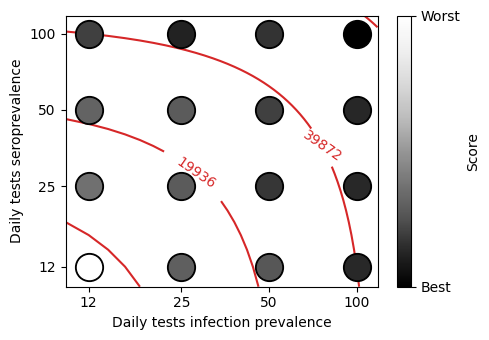

In [ ]:
fig = plt.figure(figsize=(5, 3.5))
ax = fig.add_subplot(1, 1, 1)

dense_ss_prev = np.arange(80, 1000, 2)
dense_ss_sero = np.arange(80, 1000, 2)


dense_ss_prev = np.arange(10, 120, 2)
dense_ss_sero = np.arange(10, 120, 2)


X, Y = np.meshgrid(dense_ss_prev, dense_ss_sero)

effort = np.zeros(X.shape)
for i, prev_ss in enumerate(dense_ss_prev):
    for j, sero_ss in enumerate(dense_ss_sero):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss])
        effort[j, i] = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

# levels = [80000, 160000, 240000, 320000, 400000, 480000]
levels = [10000, 20000, 40000, 80000]

true_levels = []
for l in levels:
    nearest = min(effort.flatten(), key=lambda x:abs(x-l))
    true_levels.append(nearest)

cs = ax.contour(X, Y, effort, true_levels, colors='tab:red', zorder=-10,)
ax.clabel(cs, cs.levels, fontsize=10)


cmap = mpl.colormaps['Greys_r']

highest_crps = max(avg_scores)
lowest_crps = min(avg_scores)

for score, prev_sample_size, sero_sample_size in zip(avg_scores, prev_sample_sizes, sero_sample_sizes):
    color = cmap((score - lowest_crps) / (highest_crps - lowest_crps))
    ax.scatter([prev_sample_size,], [sero_sample_size,], color=color, zorder=-1, s=300)
    ax.scatter([prev_sample_size,], [sero_sample_size,], color='k', zorder=-2, alpha=1, s=400)
    # ax.text(prev_sample_size, sero_sample_size, '{:.2f}'.format(score), color='red', zorder=100, ha='left')

cbar = plt.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=lowest_crps, vmax=highest_crps), cmap=cmap), ax=ax, label='Score')
cbar.set_ticks([lowest_crps, highest_crps])
cbar.set_ticklabels(['Best', 'Worst'])

ax.set_xlabel('Daily tests infection prevalence')
ax.set_ylabel('Daily tests seroprevalence')

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xticks(sample_sizes)
ax.set_yticks(sample_sizes)
ax.set_xticklabels(sample_sizes)
ax.set_yticklabels(sample_sizes)

ax.set_xticks([], minor=True)
ax.set_yticks([], minor=True)

fig.set_tight_layout(True)

# plt.savefig('Figure6a.pdf')

plt.show()


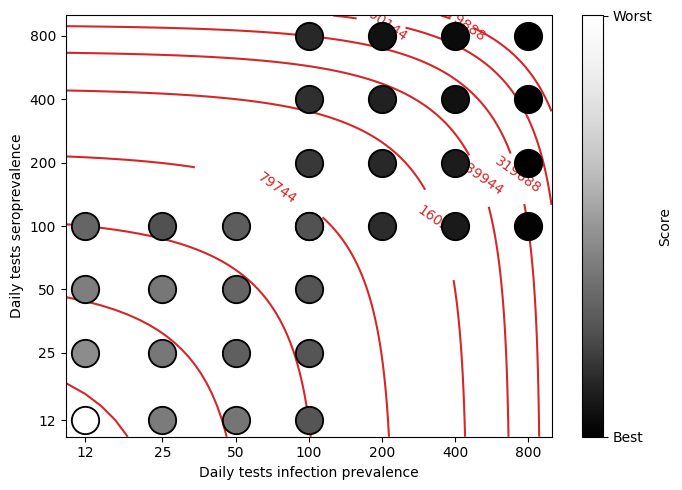

In [33]:
sample_sizes = [12, 25, 50, 100,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))


fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(1, 1, 1)

dense_ss_prev = np.arange(10, 1000, 2)
dense_ss_sero = np.arange(10, 1000, 2)


X, Y = np.meshgrid(dense_ss_prev, dense_ss_sero)

effort = np.zeros(X.shape)
for i, prev_ss in enumerate(dense_ss_prev):
    for j, sero_ss in enumerate(dense_ss_sero):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss])
        effort[j, i] = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

# levels = [80000, 160000, 240000, 320000, 400000, 480000]
levels = [10000, 20000, 40000, 80000, 160000, 240000, 320000, 400000, 480000]

true_levels = []
for l in levels:
    nearest = min(effort.flatten(), key=lambda x:abs(x-l))
    true_levels.append(nearest)

cs = ax.contour(X, Y, effort, true_levels, colors='tab:red', zorder=-10,)
ax.clabel(cs, cs.levels, fontsize=10)


cmap = mpl.colormaps['Greys_r']

other_scores = np.load('rolling_scores.npy')
other_avg_scores = np.median(other_scores, axis=0)


highest_crps = max([max(avg_scores), max(other_avg_scores)])
lowest_crps = min([min(avg_scores), min(other_avg_scores)])

for score, prev_sample_size, sero_sample_size in zip(avg_scores, prev_sample_sizes, sero_sample_sizes):
    color = cmap((score - lowest_crps) / (highest_crps - lowest_crps))
    ax.scatter([prev_sample_size,], [sero_sample_size,], color=color, zorder=-1, s=300)
    ax.scatter([prev_sample_size,], [sero_sample_size,], color='k', zorder=-2, alpha=1, s=400)
    # ax.text(prev_sample_size, sero_sample_size, '{:.2f}'.format(score), color='red', zorder=100, ha='left')



sample_sizes = [100, 200, 400, 800,]
prev_sample_sizes = np.repeat(sample_sizes, len(sample_sizes))
sero_sample_sizes = np.tile(sample_sizes, len(sample_sizes))
for score, prev_sample_size, sero_sample_size in zip(other_avg_scores, prev_sample_sizes, sero_sample_sizes):
    color = cmap((score - lowest_crps) / (highest_crps - lowest_crps))
    ax.scatter([prev_sample_size,], [sero_sample_size,], color=color, zorder=-1, s=300)
    ax.scatter([prev_sample_size,], [sero_sample_size,], color='k', zorder=-2, alpha=1, s=400)

cbar = plt.colorbar(cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=lowest_crps, vmax=highest_crps), cmap=cmap), ax=ax, label='Score')
cbar.set_ticks([lowest_crps, highest_crps])
cbar.set_ticklabels(['Best', 'Worst'])

ax.set_xlabel('Daily tests infection prevalence')
ax.set_ylabel('Daily tests seroprevalence')

ax.set_yscale('log')
ax.set_xscale('log')


all_sample_sizes = [12, 25, 50, 100, 200, 400, 800]
ax.set_xticks(all_sample_sizes)
ax.set_yticks(all_sample_sizes)
ax.set_xticklabels(all_sample_sizes)
ax.set_yticklabels(all_sample_sizes)

ax.set_xticks([], minor=True)
ax.set_yticks([], minor=True)

fig.set_tight_layout(True)

# plt.savefig('Figure6a.pdf')

plt.show()


TypeError: list indices must be integers or slices, not tuple

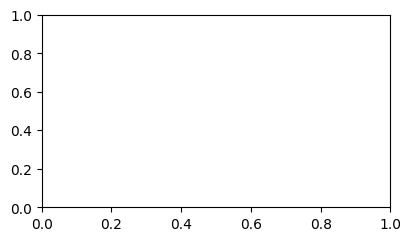

In [67]:
fig = plt.figure(figsize=(4.5, 2.5))
ax = fig.add_subplot(1, 1, 1)

for ss in sample_sizes:
    sero_scores = all_scores[:, np.where(sero_sample_sizes == ss)]
    mid = np.mean(sero_scores, axis=0)[0]
    ax.plot(sample_sizes, mid, '.-', label=ss)
    # std = np.std(sero_scores, axis=0)[0]
    # ax.fill_between(spacings, mid - std, mid + std, alpha=0.25)

# ax.set_xscale('log')
ax.spines[['right', 'top']].set_visible(False)
ax.legend(title='Sero. Sample size', loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_xlabel('Infection Sample size')
ax.set_ylabel('Score')

fig.set_tight_layout(True)

plt.show()

In [33]:
sample_sizes

[100, 200, 400, 800]

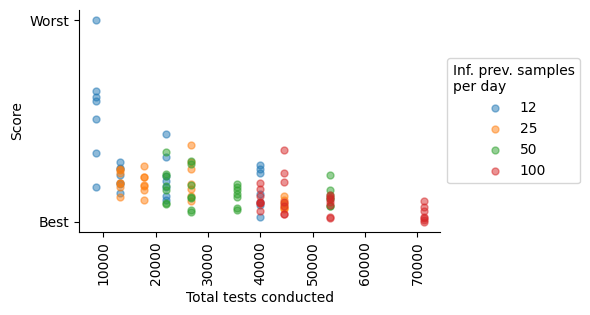

In [20]:


fig = plt.figure(figsize=(6, 3.25))

ax = fig.add_subplot(1, 1, 1)

colors = {100: 'tab:blue', 200: 'tab:orange', 400: 'tab:green', 800: 'tab:red'}
colors = {12: 'tab:blue', 25: 'tab:orange', 50: 'tab:green', 100: 'tab:red'}

sample_sizes_to_consider = {21: (0, -1), 42: (1, None), 84: (2, None)}
scores_plotted = []

for j, prev_ss in enumerate(sample_sizes):
    spacing_scores = np.asarray(all_scores)[:, np.where(prev_sample_sizes == prev_ss)]
    mid = np.median(spacing_scores, axis=0)[0]

    # spacing_scores = all_scores[1, np.where(full_spacings == spacing)]
    # mid = np.mean(spacing_scores, axis=0)

    # s0, s1 = sample_sizes_to_consider[spacing]
    # mid = mid[s0:s1]
    # for i, sample_size in enumerate(sample_sizes[s0:s1]):
    for i, sero_ss in enumerate(sample_sizes):
        surveys = survey_design.make_surveys(m, [1], [prev_ss], [1], [sero_ss], duration=7)
        effort = surveys[0].sample_size * len(surveys[0].start_dates) + surveys[1].sample_size * len(surveys[1].start_dates)

        # ax.scatter([effort,], [mid[i],], color=colors[spacing], s=50, label=spacing if i == 0 else None)
        for k in range(spacing_scores.shape[0]):
            ax.scatter([effort,], [spacing_scores[k, 0, i],], color=colors[prev_ss], s=25, label=prev_ss if k == 0 and i == 0 else None, alpha=0.5)
            scores_plotted.append(spacing_scores[k, 0, i])


ax.legend(title='Inf. prev. samples\nper day', loc='center left', bbox_to_anchor=(1, 0.5))

yticks = [np.min(scores_plotted), np.max(scores_plotted)]
ax.set_yticks(yticks)
ax.set_yticklabels(['Best', 'Worst'])

ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Total tests conducted')
ax.set_ylabel('Score')

# ax.set_xscale('log')
# ax.set_yscale('log')

# ax.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=90, ha='center')

fig.set_tight_layout(True)

# plt.savefig('Figure6b.pdf')

# ax.set_ylim(500, 17000)

plt.show()

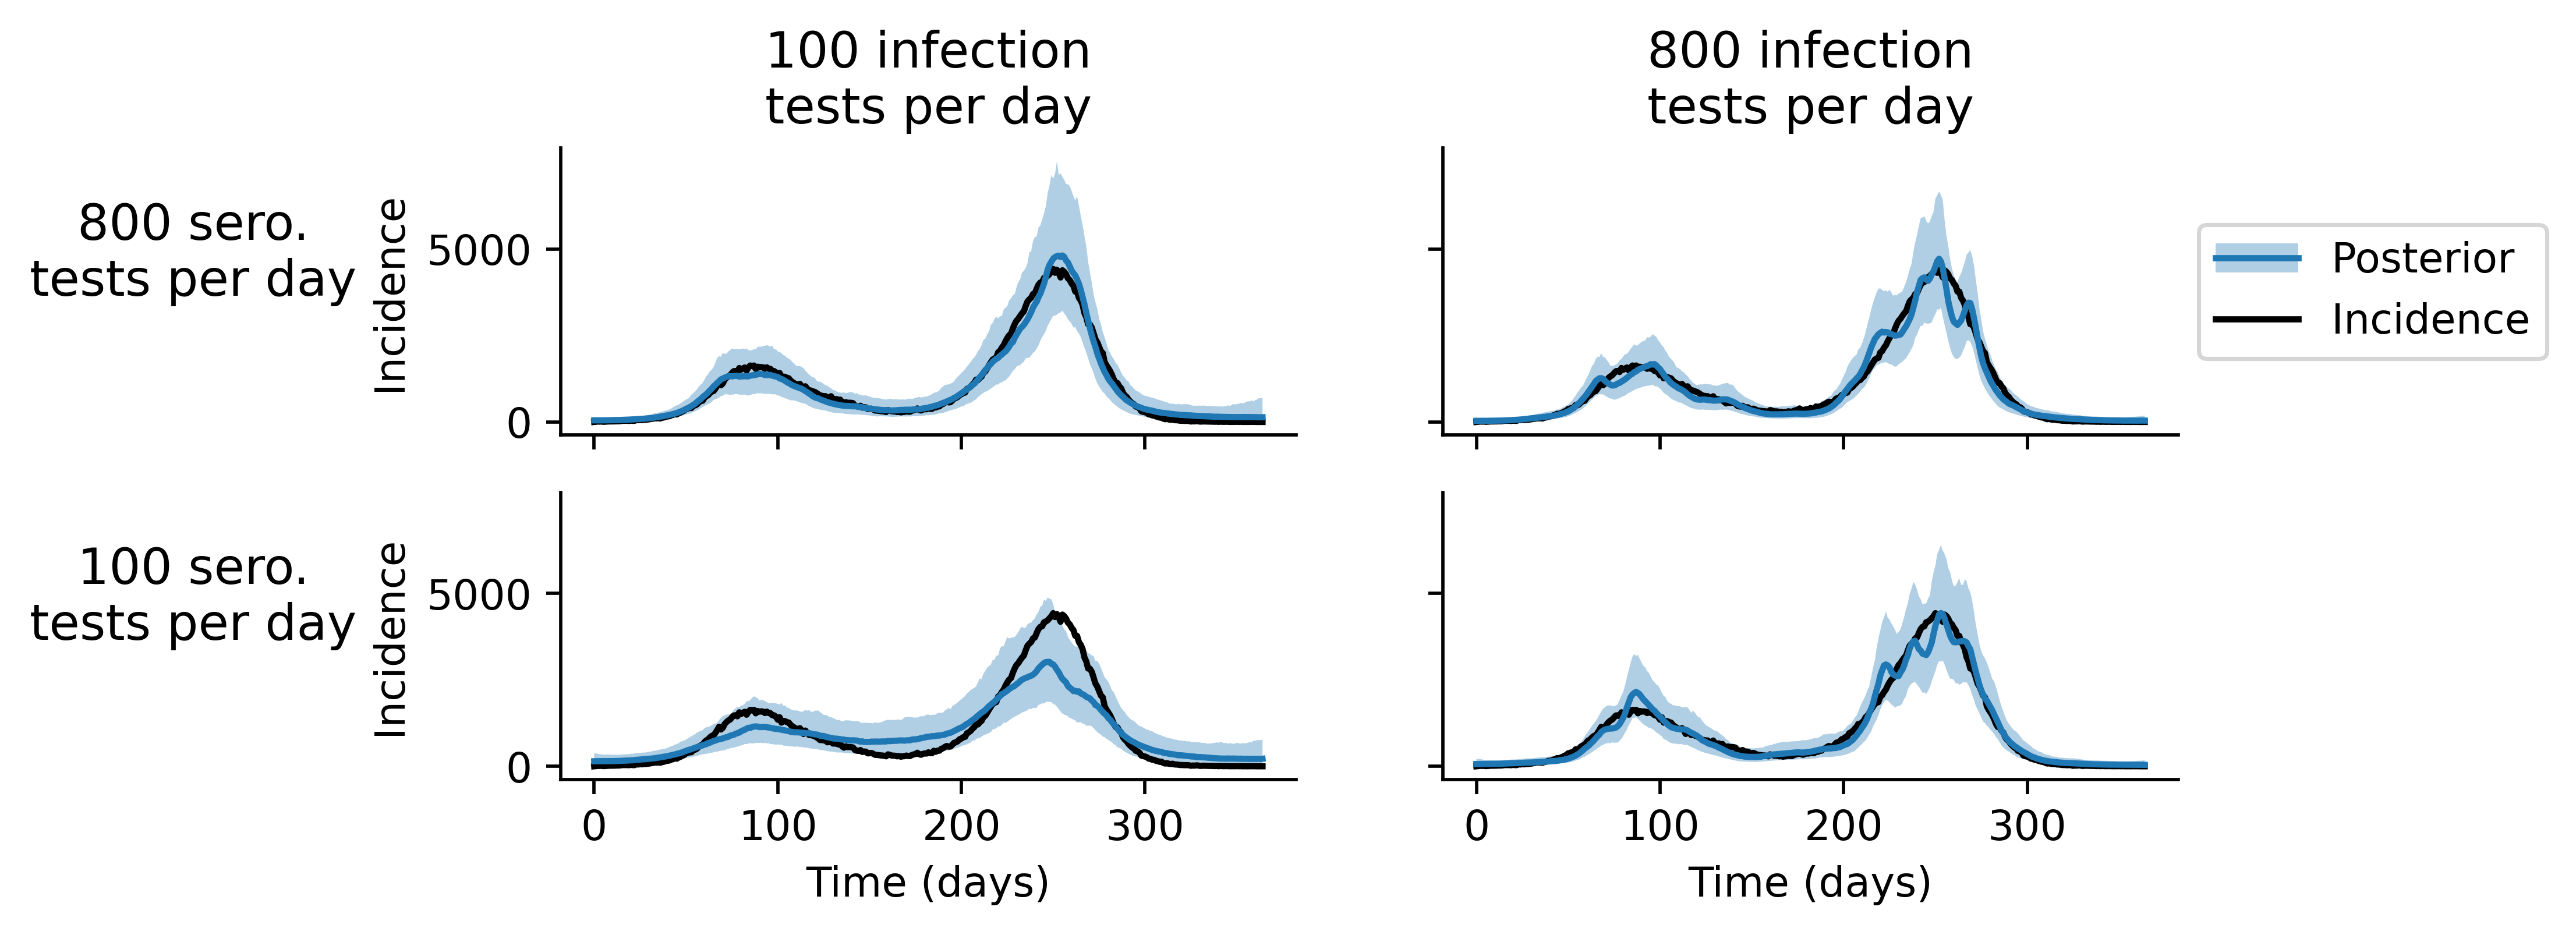

In [23]:
surveys = survey_design.make_surveys(m, spacings, prev_sample_sizes, spacings, sero_sample_sizes)

fig = plt.figure(figsize=(7, 2.75), dpi=512)

idx1 = 3
idx2 = 15
idx3 = 0
idx4 = 12

dfi = 2
df = dfs[dfi]

ax = fig.add_subplot(2, 2, 1)

fit = all_fits[dfi][idx1]


ax.plot(df['transmissions'], color='k', label='Incidence')

x = np.asarray(fit.incidence[:, :])
lower = np.percentile(x, 5, axis=0,)
upper = np.percentile(x, 95, axis=0,)
mid = np.median(x, axis=0)
tplot = np.arange(len(mid))

ax.plot(tplot, mid,)
ax.fill_between(tplot, lower, upper, alpha=0.35)
ax.spines[['right', 'top']].set_visible(False)

ax.set_ylabel('Incidence')

ax.set_title('100 infection\ntests per day')

ax.tick_params(labelbottom=False, labelleft=True)



ax = fig.add_subplot(2, 2, 2, sharex=ax, sharey=ax)

fit = all_fits[dfi][idx2]



ax.plot(df['transmissions'], color='k', label='Incidence')

x = np.asarray(fit.incidence[:, :])
lower = np.percentile(x, 5, axis=0,)
upper = np.percentile(x, 95, axis=0,)
mid = np.median(x, axis=0)
tplot = np.arange(len(mid))

ax.plot(tplot, mid,)
ax.fill_between(tplot, lower, upper, alpha=0.35)
ax.spines[['right', 'top']].set_visible(False)

legend_ax = ax

ax.set_title('800 infection\ntests per day')


ax.tick_params(labelbottom=False, labelleft=False)


ax = fig.add_subplot(2, 2, 3, sharex=ax, sharey=ax)

fit = all_fits[dfi][idx3]



ax.plot(df['transmissions'], color='k', label='Incidence')

x = np.asarray(fit.incidence[:, :])
lower = np.percentile(x, 5, axis=0,)
upper = np.percentile(x, 95, axis=0,)
mid = np.median(x, axis=0)
tplot = np.arange(len(mid))

ax.plot(tplot, mid,)
ax.fill_between(tplot, lower, upper, alpha=0.35)
ax.spines[['right', 'top']].set_visible(False)


ax.set_ylabel('Incidence')
ax.set_xlabel('Time (days)')


ax.set_title('100 sero.\ntests per day', x=-0.5, y=0.4)


ax = fig.add_subplot(2, 2, 4, sharex=ax, sharey=ax)

fit = all_fits[dfi][idx4]



l6, = ax.plot(df['transmissions'], color='k', label='Incidence')

x = np.asarray(fit.incidence[:, :])
lower = np.percentile(x, 5, axis=0,)
upper = np.percentile(x, 95, axis=0,)
mid = np.median(x, axis=0)
tplot = np.arange(len(mid))

l4, = ax.plot(tplot, mid,)
l5 = ax.fill_between(tplot, lower, upper, alpha=0.35)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel('Time (days)')

ax.set_title('800 sero.\ntests per day', x=-1.7, y=1.6)

legend_ax.legend(((l4, l5,), l6,), ['Posterior', 'Incidence'], loc='center left', bbox_to_anchor=(1, 0.5))

ax.tick_params(labelbottom=True, labelleft=False)

fig.set_tight_layout(True)

# plt.savefig('Figure6c.pdf')

plt.show()